# Topography

Loaded: (210, 649)
Detected electrodes: 64


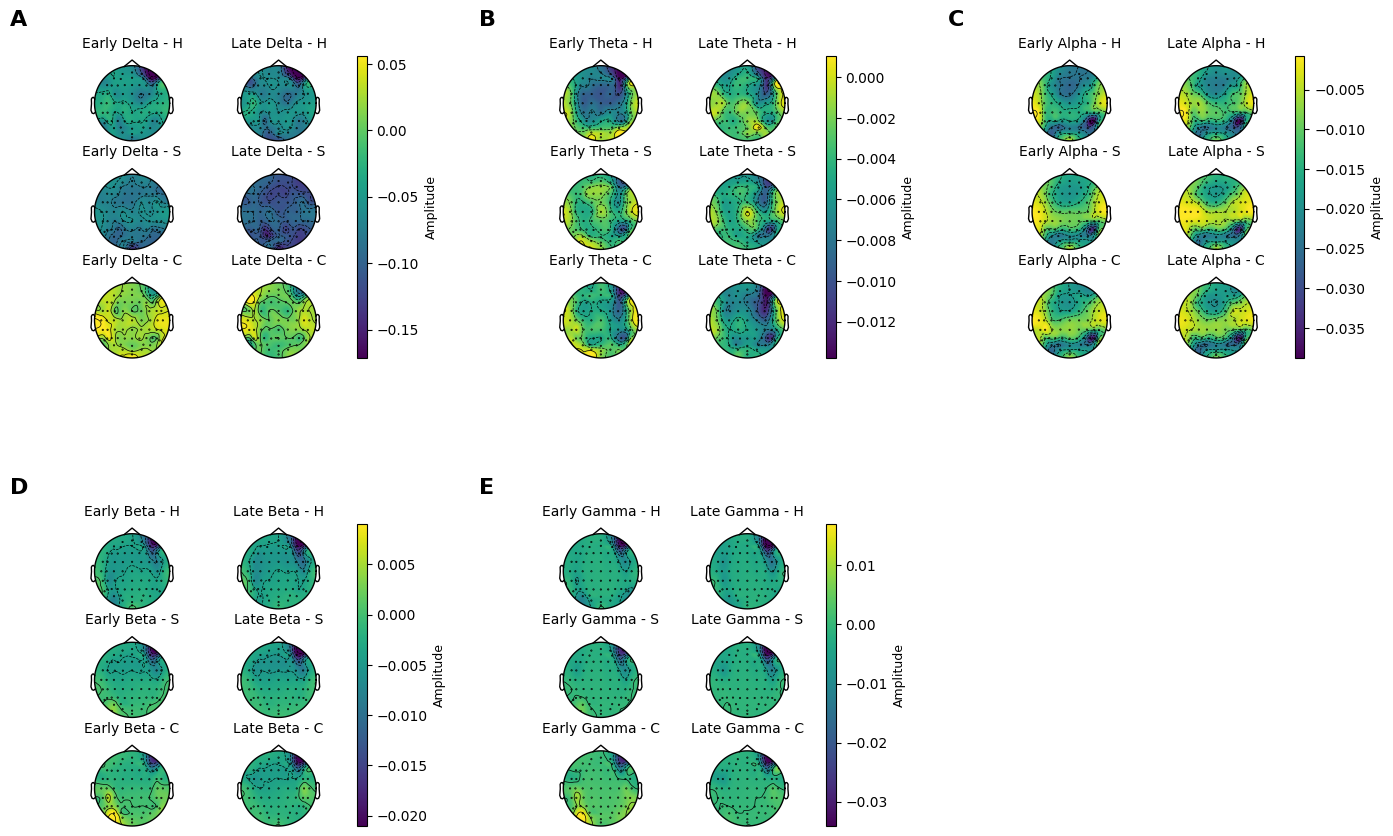

In [2]:
# ============================================================
# REAL EEG TOPOGRAPHY FIGURE
# Uses electrode-level bandpower features:
#   early_delta_Fp1, late_alpha_O2, ...
#
# Produces:
#   5 band panels × (3 conditions × 2 windows)
#   like the paper figure, but using real electrodes
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne


# ============================================================
# 1. CONFIG
# ============================================================

DATA_PATH = "../../data/features/sub-026_bpfeatures.parquet"   # <- replace

BANDS = ["delta", "theta", "alpha", "beta", "gamma"]
WINDOWS = ["early", "late"]
CONDS = ["H", "S", "C"]


# ============================================================
# 2. LOAD
# ============================================================

df = pd.read_parquet(DATA_PATH)
print(f"Loaded: {df.shape}")


# ============================================================
# 3. PARSE ELECTRODE FEATURE COLUMNS
# ============================================================

# expected format:
# early_delta_Fp1
# late_gamma_O2
pat = re.compile(r"^(early|late)_(delta|theta|alpha|beta|gamma)_(.+)$")

feature_map = {}
electrodes = set()

for col in df.columns:
    m = pat.match(col)
    if m:
        win, band, ch = m.groups()
        feature_map[(win, band, ch)] = col
        electrodes.add(ch)

electrodes = sorted(electrodes)
print(f"Detected electrodes: {len(electrodes)}")


# ============================================================
# 4. CREATE REAL EEG INFO
# ============================================================

# standard 10-20 montage
info = mne.create_info(ch_names=electrodes, sfreq=100, ch_types="eeg")
montage = mne.channels.make_standard_montage("biosemi64")
info.set_montage(montage, match_case=False)


# ============================================================
# 5. BUILD TOPO MAPS
# maps[band][window][condition] = (n_channels,)
# ============================================================

maps = {
    band: {
        win: {}
        for win in WINDOWS
    }
    for band in BANDS
}

for band in BANDS:
    for win in WINDOWS:
        for cond in CONDS:
            sub = df[df["PoemType"] == cond]

            vals = []
            for ch in electrodes:
                col = feature_map[(win, band, ch)]
                vals.append(sub[col].mean())

            maps[band][win][cond] = np.array(vals)


# ============================================================
# 6. PLOT
# ============================================================

def plot_paper_topomaps(maps, info):
    panel_labels = ["A", "B", "C", "D", "E"]

    fig = plt.figure(figsize=(16, 10))
    outer = fig.add_gridspec(2, 3, wspace=0.55, hspace=0.55)

    for b_idx, band in enumerate(BANDS):
        row = 0 if b_idx < 3 else 1
        col = b_idx if b_idx < 3 else b_idx - 3

        subgs = outer[row, col].subgridspec(
            3, 3,
            width_ratios=[1, 1, 0.07],
            wspace=0.12,
            hspace=0.28
        )

        # shared scale within band
        all_vals = []
        for cond in CONDS:
            for win in WINDOWS:
                all_vals.append(maps[band][win][cond])
        all_vals = np.concatenate(all_vals)
        vmin, vmax = all_vals.min(), all_vals.max()

        im = None
        for i, cond in enumerate(CONDS):
            for j, win in enumerate(WINDOWS):
                ax = fig.add_subplot(subgs[i, j])

                data = maps[band][win][cond]

                im, _ = mne.viz.plot_topomap(
                    data,
                    info,
                    axes=ax,
                    show=False,
                    cmap="viridis",
                    contours=6,
                    vlim=(vmin, vmax)
                )

                ax.set_title(
                    f"{win.capitalize()} {band.capitalize()} - {cond}",
                    fontsize=10
                )

        cax = fig.add_subplot(subgs[:, 2])
        cb = fig.colorbar(im, cax=cax)
        cb.set_label("Amplitude", fontsize=9)

        panel_ax = fig.add_subplot(outer[row, col])
        panel_ax.axis("off")
        panel_ax.text(
            -0.18, 1.10,
            panel_labels[b_idx],
            transform=panel_ax.transAxes,
            fontsize=16,
            fontweight="bold"
        )

    # empty panel
    ax_empty = fig.add_subplot(outer[1, 2])
    ax_empty.axis("off")

    plt.show()


# ============================================================
# 7. RUN
# ============================================================

plot_paper_topomaps(maps, info)

Found 51 subject files
Detected electrodes: 64
Processing sub-001 ...
Processing sub-002 ...
Processing sub-003 ...
Processing sub-004 ...
Processing sub-005 ...
Processing sub-006 ...
Processing sub-007 ...
Processing sub-008 ...
Processing sub-009 ...
Processing sub-010 ...
Processing sub-011 ...
Processing sub-012 ...
Processing sub-013 ...
Processing sub-014 ...
Processing sub-015 ...
Processing sub-016 ...
Processing sub-017 ...
Processing sub-018 ...
Processing sub-019 ...
Processing sub-020 ...
Processing sub-021 ...
Processing sub-022 ...
Processing sub-023 ...
Processing sub-024 ...
Processing sub-025 ...
Processing sub-026 ...
Processing sub-027 ...
Processing sub-028 ...
Processing sub-029 ...
Processing sub-030 ...
Processing sub-031 ...
Processing sub-032 ...
Processing sub-033 ...
Processing sub-034 ...
Processing sub-035 ...
Processing sub-036 ...
Processing sub-037 ...
Processing sub-038 ...
Processing sub-039 ...
Processing sub-040 ...
Processing sub-041 ...
Processing

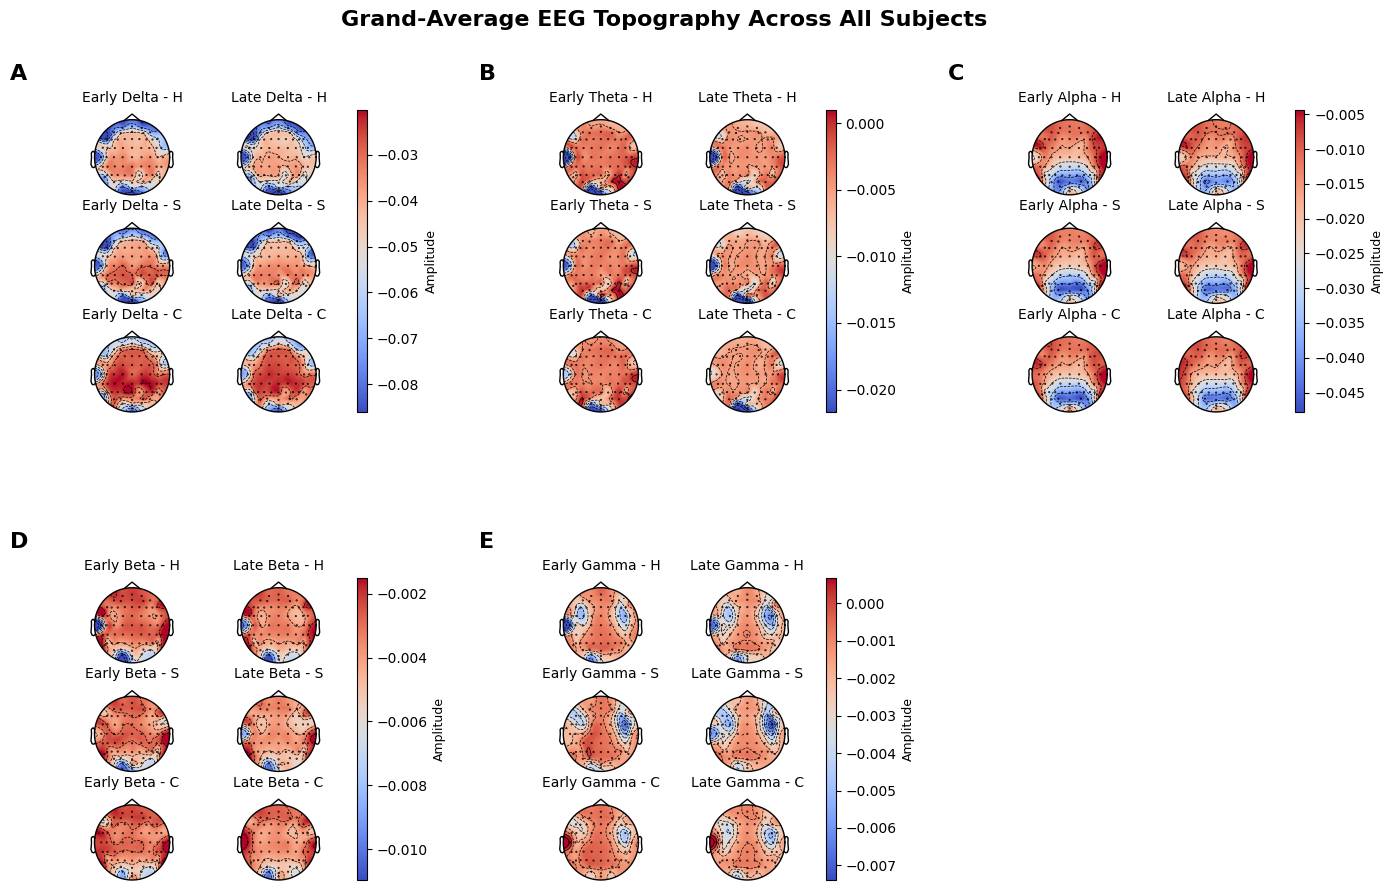

In [1]:
# ============================================================
# GRAND-AVERAGE EEG TOPOGRAPHY FIGURE (ALL SUBJECTS)
# Uses electrode-level bandpower features:
#   early_delta_Fp1, late_alpha_O2, ...
#
# Builds ONE paper-style group-level figure:
#   5 band panels × (3 conditions × 2 windows)
#
# Averages across:
#   trials within subject
#   then across all subjects
#
# Saves:
#   ../results/final/topomaps/grand_average_topomap.png
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne


# ============================================================
# 1. CONFIG
# ============================================================

DATA_DIR = Path("../../data/features/bp0")
# SAVE_DIR = Path("../results/final/topomaps")
# SAVE_DIR.mkdir(parents=True, exist_ok=True)

# SAVE_PATH = SAVE_DIR / "grand_average_topomap.png"

BANDS = ["delta", "theta", "alpha", "beta", "gamma"]
WINDOWS = ["early", "late"]
CONDS = ["H", "S", "C"]


# ============================================================
# 2. LOAD ALL SUBJECT FILES
# ============================================================

subject_files = sorted(DATA_DIR.glob("*_bpfeatures.parquet"))
print(f"Found {len(subject_files)} subject files")

if len(subject_files) == 0:
    raise FileNotFoundError(f"No subject files found in {DATA_DIR}")


# ============================================================
# 3. DISCOVER ELECTRODES FROM FIRST VALID SUBJECT
# ============================================================

pat = re.compile(r"^(early|late)_(delta|theta|alpha|beta|gamma)_(.+)$")

electrodes = None
feature_keys = None

for fp in subject_files:
    df_tmp = pd.read_parquet(fp)

    tmp_map = {}
    tmp_electrodes = set()

    for col in df_tmp.columns:
        m = pat.match(col)
        if m:
            win, band, ch = m.groups()
            tmp_map[(win, band, ch)] = col
            tmp_electrodes.add(ch)

    if len(tmp_electrodes) > 0:
        electrodes = sorted(tmp_electrodes)
        feature_keys = tmp_map
        break

if electrodes is None:
    raise ValueError("No valid electrode-level bandpower columns found")

print(f"Detected electrodes: {len(electrodes)}")


# ============================================================
# 4. CREATE EEG INFO
# ============================================================

info = mne.create_info(ch_names=electrodes, sfreq=100, ch_types="eeg")
montage = mne.channels.make_standard_montage("biosemi64")
info.set_montage(montage, match_case=False)


# ============================================================
# 5. COLLECT SUBJECT-LEVEL MAPS
# subject_maps[band][window][cond] = list of (n_channels,)
# ============================================================

subject_maps = {
    band: {
        win: {cond: [] for cond in CONDS}
        for win in WINDOWS
    }
    for band in BANDS
}

for fp in subject_files:
    subject_id = fp.stem.replace("_bpfeatures", "")
    print(f"Processing {subject_id} ...")

    df = pd.read_parquet(fp)

    # parse subject feature map
    feature_map = {}
    for col in df.columns:
        m = pat.match(col)
        if m:
            win, band, ch = m.groups()
            feature_map[(win, band, ch)] = col

    # build subject scalp maps
    for band in BANDS:
        for win in WINDOWS:
            for cond in CONDS:
                sub = df[df["PoemType"] == cond]

                vals = []
                for ch in electrodes:
                    key = (win, band, ch)

                    if key in feature_map:
                        vals.append(sub[feature_map[key]].mean())
                    else:
                        vals.append(np.nan)

                subject_maps[band][win][cond].append(np.array(vals, dtype=float))


# ============================================================
# 6. GRAND AVERAGE ACROSS SUBJECTS
# grand_maps[band][window][cond] = (n_channels,)
# ============================================================

grand_maps = {
    band: {
        win: {}
        for win in WINDOWS
    }
    for band in BANDS
}

for band in BANDS:
    for win in WINDOWS:
        for cond in CONDS:
            arr = np.vstack(subject_maps[band][win][cond])   # (n_subjects, n_channels)
            grand_maps[band][win][cond] = np.nanmean(arr, axis=0)


# ============================================================
# 7. PLOT GRAND-AVERAGE PAPER FIGURE
# ============================================================

def plot_grand_average_topomaps(maps, info, save_path=None):
    panel_labels = ["A", "B", "C", "D", "E"]

    fig = plt.figure(figsize=(16, 10))
    outer = fig.add_gridspec(2, 3, wspace=0.55, hspace=0.55)

    for b_idx, band in enumerate(BANDS):
        row = 0 if b_idx < 3 else 1
        col = b_idx if b_idx < 3 else b_idx - 3

        subgs = outer[row, col].subgridspec(
            3, 3,
            width_ratios=[1, 1, 0.07],
            wspace=0.12,
            hspace=0.28
        )

        # shared color scale within band
        all_vals = []
        for cond in CONDS:
            for win in WINDOWS:
                all_vals.append(maps[band][win][cond])
        all_vals = np.concatenate(all_vals)

        vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)

        im = None
        for i, cond in enumerate(CONDS):
            for j, win in enumerate(WINDOWS):
                ax = fig.add_subplot(subgs[i, j])

                data = maps[band][win][cond]

                im, _ = mne.viz.plot_topomap(
                    data,
                    info,
                    axes=ax,
                    show=False,
                    cmap="coolwarm",
                    contours=6,
                    vlim=(vmin, vmax)
                )

                ax.set_title(
                    f"{win.capitalize()} {band.capitalize()} - {cond}",
                    fontsize=10
                )

        cax = fig.add_subplot(subgs[:, 2])
        cb = fig.colorbar(im, cax=cax)
        cb.set_label("Amplitude", fontsize=9)

        panel_ax = fig.add_subplot(outer[row, col])
        panel_ax.axis("off")
        panel_ax.text(
            -0.18, 1.10,
            panel_labels[b_idx],
            transform=panel_ax.transAxes,
            fontsize=16,
            fontweight="bold"
        )

    # empty panel
    ax_empty = fig.add_subplot(outer[1, 2])
    ax_empty.axis("off")

    fig.suptitle("Grand-Average EEG Topography Across All Subjects",
                 fontsize=16, fontweight="bold")

    # plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ============================================================
# 8. RUN
# ============================================================

plot_grand_average_topomaps(grand_maps, info)
# print(f"\nSaved grand-average topomap -> {SAVE_PATH}")

# Power spectral density (PSD) estimates across all five canonical frequency bands (delta, theta, alpha, beta, gamma) and electrode clusters. 

Found 51 subject files
Detected clusters: ['CL1_lf', 'CL2_lft', 'CL3_lpo', 'CL4_rf', 'CL5_rft', 'CL6_rpo']
Processing sub-001_roi ...
Processing sub-002_roi ...
Processing sub-003_roi ...
Processing sub-004_roi ...
Processing sub-005_roi ...
Processing sub-006_roi ...
Processing sub-007_roi ...
Processing sub-008_roi ...
Processing sub-009_roi ...
Processing sub-010_roi ...
Processing sub-011_roi ...
Processing sub-012_roi ...
Processing sub-013_roi ...
Processing sub-014_roi ...
Processing sub-015_roi ...
Processing sub-016_roi ...
Processing sub-017_roi ...
Processing sub-018_roi ...
Processing sub-019_roi ...
Processing sub-020_roi ...
Processing sub-021_roi ...
Processing sub-022_roi ...
Processing sub-023_roi ...
Processing sub-024_roi ...
Processing sub-025_roi ...
Processing sub-026_roi ...
Processing sub-027_roi ...
Processing sub-028_roi ...
Processing sub-029_roi ...
Processing sub-030_roi ...
Processing sub-031_roi ...
Processing sub-032_roi ...
Processing sub-033_roi ...
Pr

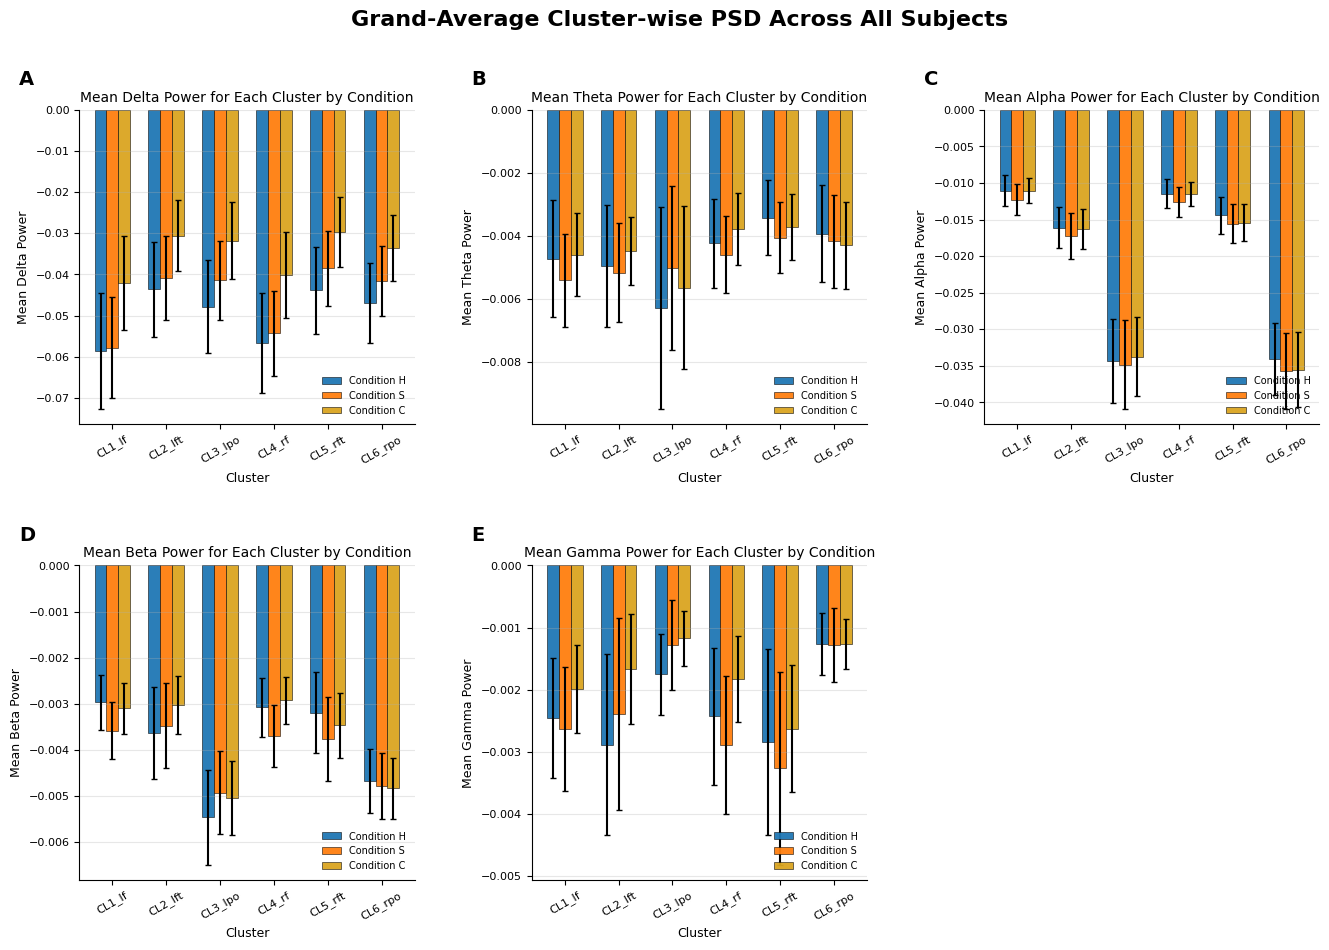

In [2]:
# ============================================================
# GRAND-AVERAGE CLUSTER PSD FIGURE (FIXED)
# Detect real cluster names from dataframe
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CONFIG
# ============================================================

DATA_DIR = Path("../../data/features/roi_ftrs")
BANDS = ["delta", "theta", "alpha", "beta", "gamma"]
CONDS = ["H", "S", "C"]


# ============================================================
# 2. LOAD SUBJECT FILES
# ============================================================

subject_files = sorted(DATA_DIR.glob("*_bpfeatures.parquet"))
print(f"Found {len(subject_files)} subject files")

if len(subject_files) == 0:
    raise FileNotFoundError(f"No subject files found in {DATA_DIR}")


# ============================================================
# 3. DETECT REAL CLUSTERS
# looks for:
# early_delta_<cluster>
# late_alpha_<cluster>
# ============================================================

df0 = pd.read_parquet(subject_files[0])

pat = re.compile(r"^(early|late)_(delta|theta|alpha|beta|gamma)_(.+)$")

clusters = set()

for col in df0.columns:
    m = pat.match(col)
    if m:
        _, _, suffix = m.groups()

        # keep only cluster-like columns, exclude electrodes
        if suffix.upper().startswith("CL"):
            clusters.add(suffix)

CLUSTERS = sorted(clusters)
print("Detected clusters:", CLUSTERS)


# ============================================================
# 4. COLLECT SUBJECT-LEVEL VALUES
# ============================================================

subject_vals = {
    band: {cl: {cond: [] for cond in CONDS} for cl in CLUSTERS}
    for band in BANDS
}

for fp in subject_files:
    subject_id = fp.stem.replace("_bpfeatures", "")
    print(f"Processing {subject_id} ...")

    df = pd.read_parquet(fp)

    for band in BANDS:
        for cl in CLUSTERS:
            early_col = f"early_{band}_{cl}"
            late_col  = f"late_{band}_{cl}"

            for cond in CONDS:
                sub = df[df["PoemType"] == cond]

                trial_vals = []

                if early_col in sub.columns:
                    trial_vals.extend(sub[early_col].dropna().tolist())

                if late_col in sub.columns:
                    trial_vals.extend(sub[late_col].dropna().tolist())

                trial_vals = np.array(trial_vals, dtype=float)

                subj_mean = np.nan if len(trial_vals) == 0 else np.mean(trial_vals)
                subject_vals[band][cl][cond].append(subj_mean)


# ============================================================
# 5. GRAND MEAN ± SEM
# ============================================================

grand_mean = {band: {cl: {} for cl in CLUSTERS} for band in BANDS}
grand_sem  = {band: {cl: {} for cl in CLUSTERS} for band in BANDS}

for band in BANDS:
    for cl in CLUSTERS:
        for cond in CONDS:
            arr = np.array(subject_vals[band][cl][cond], dtype=float)
            arr = arr[~np.isnan(arr)]

            if len(arr) == 0:
                grand_mean[band][cl][cond] = np.nan
                grand_sem[band][cl][cond] = 0.0
            elif len(arr) == 1:
                grand_mean[band][cl][cond] = arr[0]
                grand_sem[band][cl][cond] = 0.0
            else:
                grand_mean[band][cl][cond] = np.mean(arr)
                grand_sem[band][cl][cond] = np.std(arr, ddof=1) / np.sqrt(len(arr))


# ============================================================
# 6. PLOT
# ============================================================

def plot_grand_cluster_psd(grand_mean, grand_sem):
    panel_labels = ["A", "B", "C", "D", "E"]

    fig = plt.figure(figsize=(16, 10))
    outer = fig.add_gridspec(2, 3, wspace=0.35, hspace=0.45)

    colors = ["tab:blue", "tab:orange", "goldenrod"]
    width = 0.22
    x = np.arange(len(CLUSTERS))

    for b_idx, band in enumerate(BANDS):
        row = 0 if b_idx < 3 else 1
        col = b_idx if b_idx < 3 else b_idx - 3

        ax = fig.add_subplot(outer[row, col])

        for i, cond in enumerate(CONDS):
            means = [grand_mean[band][cl][cond] for cl in CLUSTERS]
            sems  = [grand_sem[band][cl][cond] for cl in CLUSTERS]

            ax.bar(
                x + (i - 1) * width,
                means,
                width=width,
                yerr=sems,
                capsize=2,
                color=colors[i],
                edgecolor="black",
                linewidth=0.4,
                alpha=0.95,
                label=f"Condition {cond}"
            )

        ax.set_xticks(x)
        ax.set_xticklabels(CLUSTERS, rotation=30)
        ax.set_xlabel("Cluster", fontsize=9)
        ax.set_ylabel(f"Mean {band.capitalize()} Power", fontsize=9)
        ax.set_title(f"Mean {band.capitalize()} Power for Each Cluster by Condition", fontsize=10)
        ax.grid(axis="y", alpha = 0.3)
        ax.tick_params(axis="both", labelsize=8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(fontsize=7, frameon=False, loc="lower right")

        ax.text(-0.18, 1.08, panel_labels[b_idx],
                transform=ax.transAxes, fontsize=14, fontweight="bold")

    ax_empty = fig.add_subplot(outer[1, 2])
    ax_empty.axis("off")

    fig.suptitle("Grand-Average Cluster-wise PSD Across All Subjects",
                 fontsize=16, fontweight="bold")

    plt.show()
    plt.close(fig)


plot_grand_cluster_psd(grand_mean, grand_sem)

# Behavioral Ratings Violin Plot for All Subjects

```python
# ============================================================
# BEHAVIORAL RATINGS DISTRIBUTION FIGURE
# Violin + Box + Jitter Plot
# Replicates uploaded reference figure
# ============================================================
```